About the homework: In some tasks, in addition to writing code, answers to questions and conclusions are required (there are special Markdown cells marked with **Answer**).

The ability to analyze the results of experiments is an important skill. Therefore, answers carry more weight than the code: the code accounts for 30% of the task grade, while answers to questions account for 70%.

In [3016]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

Download the [UCI Heart Disease Data](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data/data)

In [3018]:
df = pd.read_csv('/content/heart_disease_uci.csv')
# df = pd.read_csv('heart_disease_uci.csv') - I use Jupyter Notebook through Anaconda, not Colab, so I leave the line I have used just in case.
df.sample(4)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
649,650,55,Male,Switzerland,asymptomatic,115.0,0.0,NaN,normal,155.0,False,0.1,flat,NaN,NaN,1
613,614,43,Male,Switzerland,asymptomatic,140.0,0.0,False,st-t abnormality,140.0,True,0.5,upsloping,NaN,reversable defect,2
320,321,36,Male,Hungary,non-anginal,112.0,340.0,False,normal,184.0,False,1.0,flat,NaN,normal,0
42,43,71,Female,Cleveland,atypical angina,160.0,302.0,False,normal,162.0,False,0.4,upsloping,2.0,normal,0


# Task 1 (2 points)

Compute the mean, quartiles(Q1, Q2, Q3) and std for every numerical feature (also include column `'id'`).

In [3021]:
means_quart_std = pd.DataFrame({'Mean - quartiles - std': ['mean', 'Q1', 'Q2', 'Q3', 'std'], 'id': [df['id'].mean(), df['id'].quantile(0.25), df['id'].quantile(0.50), df['id'].quantile(0.75), df['id'].std()], 'age': [df['age'].mean(), df['age'].quantile(0.25), df['age'].quantile(0.50), df['age'].quantile(0.75), df['age'].std()], 'trestbps': [df['trestbps'].mean(), df['trestbps'].quantile(0.25), df['trestbps'].quantile(0.50), df['trestbps'].quantile(0.75), df['trestbps'].std()], 'chol': [df['chol'].mean(), df['chol'].quantile(0.25), df['chol'].quantile(0.50), df['chol'].quantile(0.75), df['chol'].std()], \
                     'thalch': [df['thalch'].mean(), df['thalch'].quantile(0.25), df['thalch'].quantile(0.50), df['thalch'].quantile(0.75), df['thalch'].std()], 'oldpeak': [df['oldpeak'].mean(), df['oldpeak'].quantile(0.25), df['oldpeak'].quantile(0.50), df['oldpeak'].quantile(0.75), df['oldpeak'].std()], 'ca': [df['ca'].mean(), df['ca'].quantile(0.25), df['ca'].quantile(0.50), df['ca'].quantile(0.75), df['ca'].std()]})
means_quart_std

,Mean - quartiles - std,id,age,trestbps,chol,thalch,oldpeak,ca
0,mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375
1,Q1,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000
2,Q2,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000
3,Q3,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000
4,std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653


In [3022]:
df.isna().sum().sort_values(ascending=False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
thalch       55
exang        55
chol         30
restecg       2
id            0
age           0
sex           0
dataset       0
cp            0
num           0
dtype: int64

Let's look into `'id'` feature. Does it seem to differ from other variables? If yes, how?

**Answer** Unlike other variables, the values of 'id' simply increases with every observation, and the value is unique for each observation. This is since in this anonymized dataset each individual receives numerical ID from 1 to 920.

Draw the distribution of the `'id'` variable. Describe it and explain, why does it look like this. What useful information about heart disease can be extracted from it?

<function matplotlib.pyplot.show(close=None, block=None)>

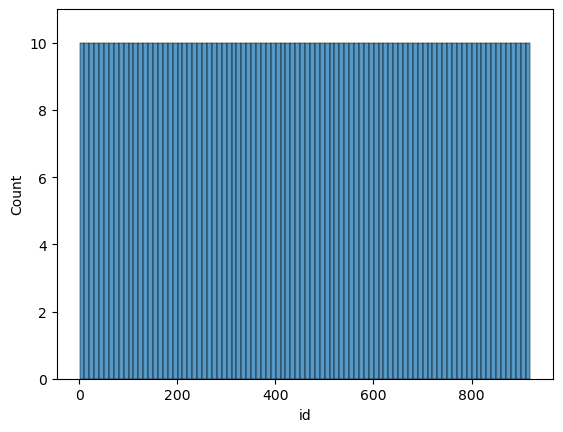

In [3026]:
sns.histplot(df, x='id', bins = 92)

plt.ylim(0,11)
plt.show

**Answer** From the histplot we can see that the distribution of 'id' is symmetrical with no mode, and every value has equal frequency of appearance (10 for each bin out of 92 for 920 observations). This is since for every observation, the value of 'id' is unique. There is thus no reason to conduct any arithmetical and/or statistical operations with it further. 'id' cannot tell us anything useful about heart desease.

# Task 2 (2 points)

Let's search for outliers in numerical variables (do not include `'id'`).

First of all, draw boxplots for every one of them on one figure.

Hint: use `plt.subplots`

Describe the plots:



*   Which features do not have any outliers?
*   Which features seem to have the maximum number of outliers?
*   For which features it may be hard to count the number of outliers? Why?





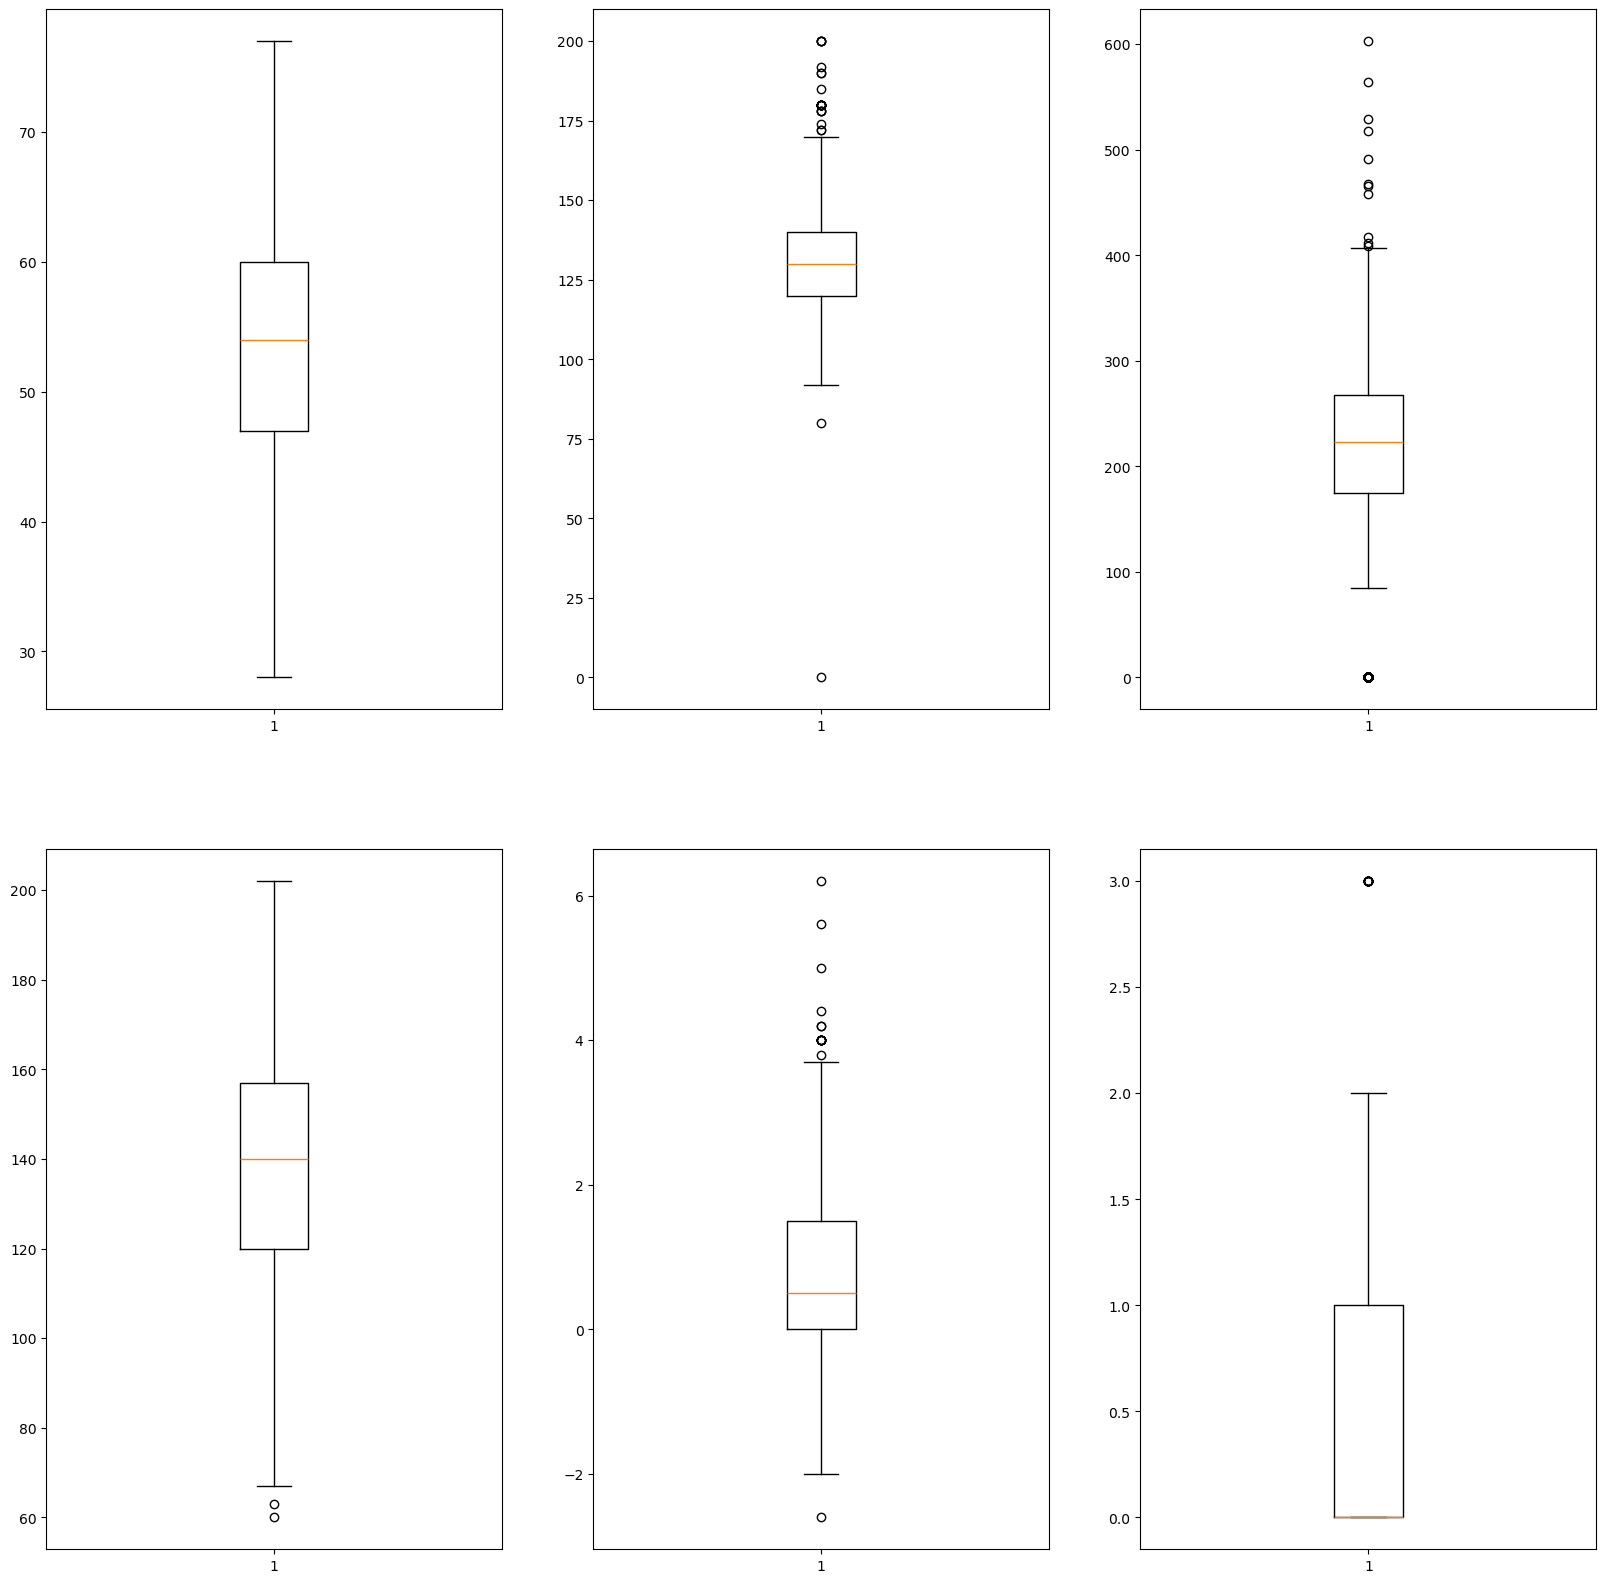

In [3031]:
#YOUR CODE
fig, ax = plt.subplots(ncols = 3, nrows = 2, figsize = (20,20))

ax[0][0].boxplot(df['age'].dropna(), vert=True)

ax[0][1].boxplot(df['trestbps'].dropna(), vert=True)

ax[0][2].boxplot(df['chol'].dropna(), vert=True)

ax[1][0].boxplot(df['thalch'].dropna(), vert=True)

ax[1][1].boxplot(df['oldpeak'].dropna(), vert=True)

ax[1][2].boxplot(df['ca'].dropna(), vert=True)

plt.show()

**Answer** 1. Only 'age' does not seem to have any outliers whatsoever based in the boxplots drawn. 2. Visually, 'trestbps', 'chol' and 'thalch' seem to have the most amount of outliers compared to other numerical features. However, the 'ca' feature has a very bold circle representing the outliers, so it might be that there are lots of outliers in 'ca' with the same values. 3. 'ca' feature seems to be the most difficult to count in terms of outliers based upon the boxplots, since the bold circle representing the outliers may signify a lot of outliers of the same value. Same is for 'chol' outliers who are below the minimum. It should be noted, however, that a lot a missing values were dropped from the 'ca' feature (622, as can be seen from the dictionary of missing values in the task 1), and this should complicate further calculations.

Use the $1.5IQR$ approach and count the number of outliers for each column.

In [3034]:
muage = df['age'].mean()
stdage = df['age'].std()

low_3sage = muage - 3 * stdage
up_3sage = muage + 3 * stdage

mutrestbps = df['trestbps'].mean()
stdtrestbps = df['trestbps'].std()

low_3strestbps = mutrestbps - 3 * stdtrestbps
up_3strestbps = mutrestbps + 3 * stdtrestbps

muchol = df['chol'].mean()
stdchol = df['chol'].std()

low_3schol = muchol - 3 * stdchol
up_3schol = muchol + 3 * stdchol

muthalch = df['thalch'].mean()
stdthalch = df['thalch'].std()

low_3sthalch = muthalch - 3 * stdthalch
up_3sthalch = muthalch + 3 * stdthalch

muoldpeak = df['oldpeak'].mean()
stdoldpeak = df['oldpeak'].std()

low_3soldpeak = muoldpeak - 3 * stdoldpeak
up_3soldpeak = muoldpeak + 3 * stdoldpeak

muca = df['ca'].mean()
stdca = df['ca'].std()

low_3sca = muca - 3 * stdca
up_3sca = muca + 3 * stdca

outliers = pd.DataFrame({'age outliers': [len(df[(df['age'] < low_3sage) | (df['age'] > up_3sage)])], 'trestbps outliers': \
                       [len(df[(df['trestbps'] < low_3strestbps) | (df['trestbps'] > up_3strestbps)])], 'chol outliers': \
                         [len(df[(df['chol'] < low_3schol) | (df['chol'] > up_3schol)])], 'thalch outliers': \
                        [len(df[(df['thalch'] < low_3sthalch) | (df['thalch'] > up_3sthalch)])], 'oldpeak outliers': \
                        [len(df[(df['oldpeak'] < low_3soldpeak) | (df['oldpeak'] > up_3soldpeak)])], 'ca outliers': \
                        [len(df[(df['ca'] < low_3sca) | (df['ca'] > up_3sca)])]})
outliers

,age outliers,trestbps outliers,chol outliers,thalch outliers,oldpeak outliers,ca outliers
0,0,8,2,0,7,0


For the feature with most outliers, draw the histogram and depict the bounds. Do the bounds seem too tight or too wide? Is deleting all outliers for this feature a good idea?

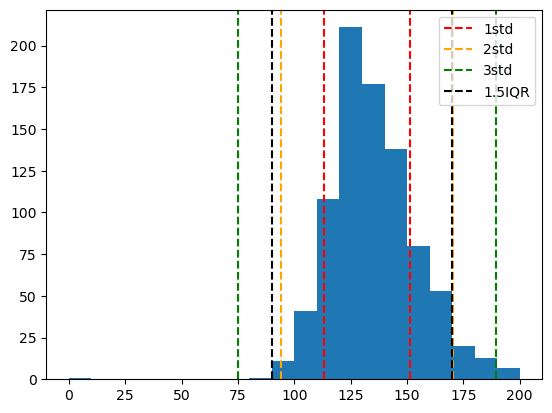

In [3036]:
q1trestbps = df['trestbps'].quantile(0.25)
q3trestbps = df['trestbps'].quantile(0.75)
iqrtrestbps = q3trestbps - q1trestbps

low_iqrtrestbps = q1trestbps - iqrtrestbps * 1.5
up_iqrtrestbps = q3trestbps + iqrtrestbps * 1.5


low_1s = mutrestbps - 1 * stdtrestbps
up_1s = mutrestbps + 1 * stdtrestbps


low_2s = mutrestbps - 2 * stdtrestbps
up_2s = mutrestbps + 2 * stdtrestbps

plt.hist(df['trestbps'], bins=20)


plt.axvline(low_1s, linestyle='--', c='red',   label='1std')
plt.axvline(up_1s,  linestyle='--', c='red')


plt.axvline(low_2s, linestyle='--', c='orange',   label='2std')
plt.axvline(up_2s,  linestyle='--', c='orange')

plt.axvline(low_3strestbps, linestyle='--', c='green',   label='3std')
plt.axvline(up_3strestbps,  linestyle='--', c='green')


plt.axvline(low_iqrtrestbps, linestyle='--', c='black',   label='1.5IQR')
plt.axvline(up_iqrtrestbps,  linestyle='--', c='black')


plt.legend(loc='upper right')
plt.show()


**Answer** The bounds seem to be a bit tight due to the presence of an outlier; the distribution without the outlier reminds us of a normal distribution. We can see that there is are quite many outliers above the 3 standard deviations above the mean, and only a few (or one) outlier below the the 3 standard deviations below the mean. Deleting the one that is below may be a good idea. However, the value of 0 may simply signify a missing value, and in this sense it would be more rational to fill this missing value with a mean value instead of 0. Other outliers can be safely deleted, if there are not that many of them.

# Task 3 (2 points)

Find the group (or groups) of people that will be deleted, if we delete all the outliers for the feature with the most outliers from the previous task.

In [3040]:
df[(df['trestbps'] < low_3strestbps) | (df['trestbps'] > up_3strestbps)]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
126,127,56,Female,Cleveland,asymptomatic,200.0,288.0,True,lv hypertrophy,133.0,True,4.0,downsloping,2.0,reversable defect,3
188,189,54,Male,Cleveland,atypical angina,192.0,283.0,False,lv hypertrophy,195.0,False,0.0,upsloping,1.0,reversable defect,1
338,339,39,Male,Hungary,atypical angina,190.0,241.0,False,normal,106.0,False,0.0,NaN,NaN,NaN,0
548,549,54,Male,Hungary,asymptomatic,200.0,198.0,False,normal,142.0,True,2.0,flat,NaN,NaN,1
680,681,61,Male,Switzerland,non-anginal,200.0,0.0,NaN,st-t abnormality,70.0,False,0.0,NaN,NaN,normal,3
701,702,64,Female,Switzerland,asymptomatic,200.0,0.0,False,normal,140.0,True,1.0,flat,NaN,normal,3
753,754,55,Male,VA Long Beach,non-anginal,0.0,0.0,False,normal,155.0,False,1.5,flat,NaN,NaN,3
896,897,61,Male,VA Long Beach,asymptomatic,190.0,287.0,True,lv hypertrophy,150.0,True,2.0,downsloping,NaN,NaN,4


**Answer** Now we can see that indeed the only value below the 3 standard deviations below the mean is equal to 0 (0.0). This may simply mean a missing value. It can be then refilled with a mean value. Others can be safely deleted, since there are not many of them.

# Task 4 (2 points)

Check the proportion of missing values in the dataset. What approach can be used to tackle the problem for every variable?

In [3044]:
df.isna().sum().sort_values(ascending=False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
thalch       55
exang        55
chol         30
restecg       2
id            0
age           0
sex           0
dataset       0
cp            0
num           0
dtype: int64

**Answer** We can see that from the columns containing missing values, 'thal', 'slope', 'fbs', 'exang' and 'restecg' are categorical variables (with 'fbs' and 'exang' being binary ones), while the others are numerical. For categorical variables, it would be more efficient to refill the missing values with the mode, while the observations where the restecg values are missing we can safely delete, since there are just 2 of them. Missing values for numerical variables we can refill with means of the corresponding variables. However, for 'ca' I would propose to refill it with random values from the corresponding interval, since otherwise it would greatly bias the distribution due to a significant amount of missing values; it would probably be even more efficient to just remove this feature from the analysis. For this homework, I suppose, it would be sufficient to fill it with mode (since 'ca' is a discrete numerical variable, it would be more efficient to use mode).

Fill the missing values, for categorical features create new category `'NOT GIVEN'`

In [3047]:
fill_dict = {'New category': 'NOT GIVEN'}

df['fbs'] = df['fbs'].fillna(fill_dict['New category'])
df['thal'] = df['thal'].fillna(fill_dict['New category'])
df['slope'] = df['slope'].fillna(fill_dict['New category'])
df['exang'] = df['exang'].fillna(fill_dict['New category'])
df['restecg'] = df['restecg'].fillna(fill_dict['New category'])
df['ca'] = df['ca'].fillna(df['ca'].mode().iloc[0])
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].mean())
df['thalch'] = df['thalch'].fillna(df['thalch'].mean())
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].mean())
df['chol'] = df['chol'].fillna(df['chol'].mean())
df.isna().sum().sort_values(ascending=False)

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

# Task 5 (2 points)

Convert every numerical variable into z-scores:

In [3050]:
from scipy.stats import zscore

zscores = pd.DataFrame({"age": zscore(df['age']), 'trestbps': zscore(df['trestbps']), \
                        'chol': zscore(df['trestbps']), 'thalch': zscore(df['trestbps']), 'oldpeak': zscore(df['oldpeak']), \
                       'ca': zscore(df['ca'])})
zscores

,age,trestbps,chol,thalch,oldpeak,ca
0,1.007386,0.698041,0.698041,0.698041,1.349421,-0.361400
1,1.432034,1.511761,1.511761,1.511761,0.589832,4.411152
2,1.432034,-0.658158,-0.658158,-0.658158,1.634267,2.820301
3,-1.752828,-0.115679,-0.115679,-0.115679,2.488805,-0.361400
4,-1.328180,-0.115679,-0.115679,-0.115679,0.494884,-0.361400
...,...,...,...,...,...,...
915,0.051927,-0.278423,-0.278423,-0.278423,-0.834397,-0.361400
916,0.901224,0.000000,0.000000,0.000000,0.000000,-0.361400
917,0.158089,-0.549662,-0.549662,-0.549662,-0.834397,-0.361400
918,0.476575,0.000000,0.000000,0.000000,0.000000,-0.361400


Find the most extreme value in the dataset: in what column is it in?

In [3052]:
zscores.max()

age         2.493654
trestbps    3.681680
chol        3.681680
thalch      3.681680
oldpeak     5.052418
ca          4.411152
dtype: float64

**Answer** As we can see, the most extreme value is contained in the column 'oldpeak', for which the maximum z-score value is 5.052418.

Draw the distributions on one plot. Adjust the visible area of the histogram in such way, that the bar for the most extreme value is visible. It is ok to cut  very high bars.

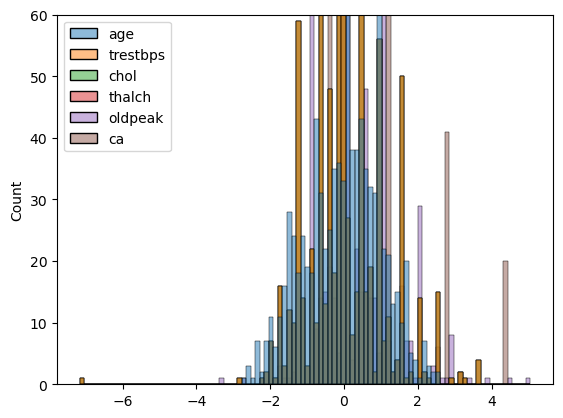

In [3055]:
sns.histplot(data = zscores)

plt.ylim(0,60)
plt.show()